<a href="https://colab.research.google.com/github/thaysfaleiro-a11y/Mini-projeto-SCTEC/blob/main/Projeto_IA_SCTEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Célula 1: Importação de Bibliotecas

In [ ]:
# ==============================================================================
# BIBLIOTECAS E DEPENDÊNCIAS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Biblioteca para balancear classes (SMOTE)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import auth
import pandas as pd
import gspread
from google.auth import default

# 1. Autentica sua conta do Google (vai abrir uma janela para você clicar em "Permitir")
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Abre a planilha diretamente pelo nome dela no seu Drive
nome_da_planilha = 'manutencao_preditivaa333'
planilha = gc.open(nome_da_planilha)

# 3. Seleciona a primeira aba da planilha e carrega os dados
aba = planilha.sheet1
dados = aba.get_all_values()

# 4. Transforma em um DataFrame do Pandas (definindo a primeira linha como cabeçalho)
df = pd.DataFrame(dados[1:], columns=dados[0])

# Exibe as primeiras linhas
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,,,,,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [ ]:
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

,Registration State,Violation Description,count
0,CA,Double Parking,50234
1,NJ,No Parking,50083
2,NY,Bus Stop,50138
3,TX,Fire Hydrant,50540


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import auth
import pandas as pd
import gspread
from google.auth import default

# 1. Isso vai pedir para você fazer login e dar permissão de acesso às planilhas
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Abra a planilha usando APENAS o nome dela (sem o caminho de pastas do Drive)
nome_da_planilha = 'manutencao_preditivaa333'
planilha = gc.open(nome_da_planilha)

# 3. Puxa os dados da primeira aba
aba = planilha.sheet1
dados = aba.get_all_values()

# 4. Converte para o DataFrame do Pandas
df = pd.DataFrame(dados[1:], columns=dados[0])

# Exibe as primeiras linhas da planilha
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,,,,,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


Célula 2: Fase 1 – Análise Exploratória (EDA)

Dimensões do Dataset: 10000 linhas e 14 colunas.

--- Tipos de Dados ---
udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                   object
falha_hdf                   object
falha_pwf                   object
falha_osf                   object
falha_rnf                   object
dtype: object

--- Resumo Estatístico Descritivo ---


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


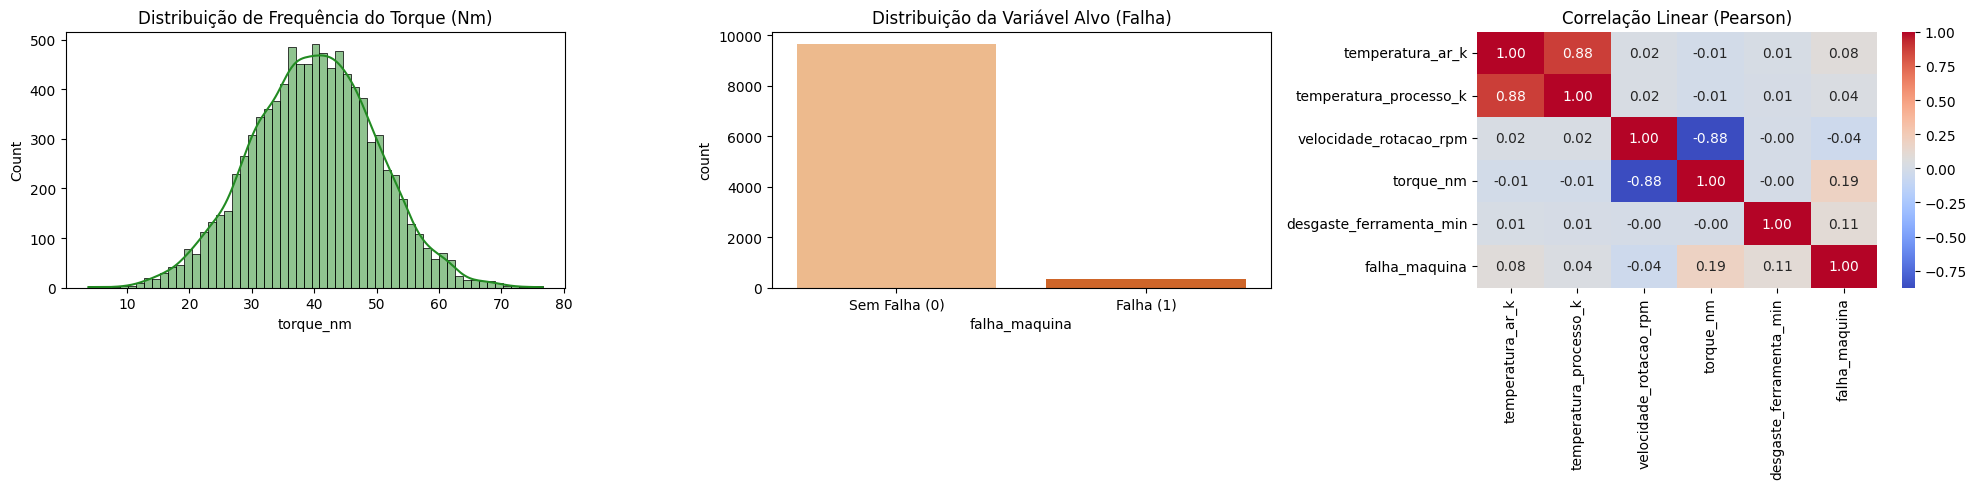

In [ ]:
# ==============================================================================
# FASE 1: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ==============================================================================

# 1. Carregamento dos dados
# df = pd.read_csv('manutencao_preditiva.csv') # Este arquivo não foi encontrado, usando 'df' carregado da planilha do Google.

# 2. Limpeza inicial de linhas de metadados corrompidas (garantindo que o UDI seja numérico)
df['udi'] = pd.to_numeric(df['udi'], errors='coerce')
df = df.dropna(subset=['udi'])

# Convertendo colunas numéricas importadas como texto de volta para float
cols_num = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Dimensões do dataset
print(f"Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# 4. Tipos de dados e resumo descritivo
print("--- Tipos de Dados ---")
print(df.dtypes)
print("\n--- Resumo Estatístico Descritivo ---")
display(df.describe())

# 5. Plotagem dos 3 Gráficos Analíticos
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: Histograma do Torque
sns.histplot(df['torque_nm'].dropna(), kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Distribuição de Frequência do Torque (Nm)')

# Gráfico 2: Prova Visual do Desbalanceamento
sns.countplot(x='falha_maquina', data=df, ax=axes[1], palette='Oranges')
axes[1].set_title('Distribuição da Variável Alvo (Falha)')
axes[1].set_xticklabels(['Sem Falha (0)', 'Falha (1)'])

# Gráfico 3: Matriz de Correlação
num_only = df.select_dtypes(include=[np.number]).drop(columns=['udi'])
sns.heatmap(num_only.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Correlação Linear (Pearson)')

plt.tight_layout()
plt.show()

In [ ]:
print("--- Verificação de Valores Ausentes nas Colunas de Falha ---")
display(df.filter(like='falha_').isnull().sum())

--- Verificação de Valores Ausentes nas Colunas de Falha ---


,0
falha_maquina,0
falha_twf,0
falha_hdf,0
falha_pwf,0
falha_osf,0
falha_rnf,0


### Como Carregar um Arquivo CSV para o Google Colab:

Existem algumas maneiras de fazer upload de arquivos para o ambiente do Google Colab:

**1. Usando o Painel de Arquivos (Recomendado para arquivos pequenos a médios):**

   * No lado esquerdo da interface do Colab, clique no ícone de pasta (`📂`) para abrir o painel "Arquivos".
   * Clique no ícone "Carregar para o armazenamento da sessão" (parece uma seta apontando para cima). Uma janela de diálogo será aberta.
   * Navegue até o seu arquivo `manutencao_preditiva.csv` no seu computador, selecione-o e clique em "Abrir" ou "Carregar".
   * O arquivo será carregado para o diretório `/content/` no seu ambiente Colab. Uma vez carregado, você poderá acessá-lo usando `pd.read_csv('manutencao_preditiva.csv')`.

**2. Usando o Google Drive (Recomendado para arquivos maiores ou para persistência):**

   * Primeiro, você precisa montar seu Google Drive no Colab. Execute o seguinte código em uma célula:
     ```python
     from google.colab import drive
     drive.mount('/content/drive')
     ```
   * Siga o link que aparece, selecione sua conta do Google e permita o acesso.
   * Faça upload do seu arquivo `manutencao_preditiva.csv` para uma pasta no seu Google Drive (por exemplo, `Colab Notebooks`).
   * Depois que o Drive estiver montado, você poderá acessar o arquivo usando o caminho completo. Por exemplo, se você carregou o arquivo para `Meu Drive/Colab Notebooks/manutencao_preditiva.csv`:
     ```python
     df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/manutencao_preditiva.csv')
     ```

**3. Via código Python (para uploads programáticos ou arquivos menores):**

   * Execute o seguinte código em uma célula e, em seguida, use o botão de "Escolher Arquivos" que aparecerá para selecionar o seu CSV:
     ```python
     from google.colab import files
     uploaded = files.upload()

     for fn in uploaded.keys():
       print('User uploaded file "{name}" with length {length} bytes'.format(
           name=fn, length=len(uploaded[fn])))
     ```
   * Após o upload, o arquivo estará disponível no diretório raiz do Colab e você poderá carregá-lo com `pd.read_csv('manutencao_preditiva.csv')`.

Depois de carregar o arquivo usando um desses métodos, execute novamente a célula que contém `df = pd.read_csv('manutencao_preditiva.csv')`.

Célula 3: Fase 2 – Limpeza e Tratamento de Dados (Data Prep)

Removidas 0 linhas duplicadas do dataset.
Nulos em 'temperatura_ar_k' imputados com a mediana: 300.1
Nulos em 'temperatura_processo_k' imputados com a mediana: 310.1
Nulos em 'velocidade_rotacao_rpm' imputados com a mediana: 1504.0
Nulos em 'torque_nm' imputados com a mediana: 40.1


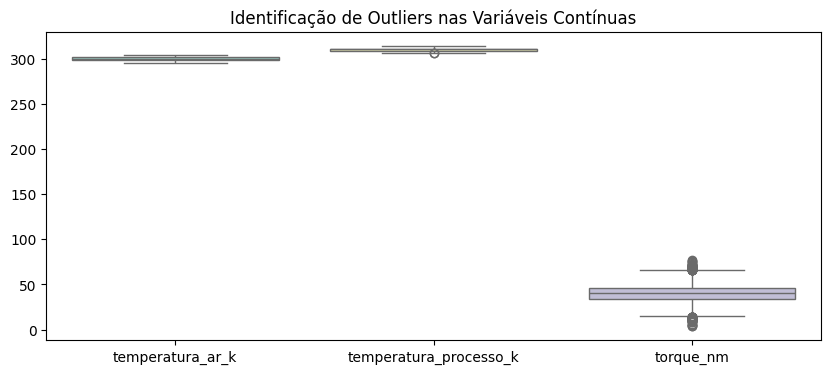

In [ ]:
# ==============================================================================
# FASE 2: LIMPEZA E TRATAMENTO DE DADOS
# ==============================================================================

# 1. Identificar e remover duplicatas
duplicadas_antes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removidas {duplicadas_antes} linhas duplicadas do dataset.")

# 2. Imputação de dados nulos por Mediana
# Justificativa: A mediana foi selecionada por ser robusta à distorção de outliers,
# especialmente na velocidade de rotação (rpm), que possui assimetria positiva acentuada.
colunas_nulas = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']
for col in colunas_nulas:
    mediana_valor = df[col].median()
    df[col] = df[col].fillna(mediana_valor)
    print(f"Nulos em '{col}' imputados com a mediana: {mediana_valor}")

# 3. Geração de Boxplots para Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['temperatura_ar_k', 'temperatura_processo_k', 'torque_nm']], palette='Set3')
plt.title('Identificação de Outliers nas Variáveis Contínuas')
plt.show()

In [ ]:
# 4. Aplicação de One-Hot Encoding nas variáveis categóricas 'tipo' e 'id_produto'
# df_encoded = pd.get_dummies(df, columns=['tipo', 'id_produto'], drop_first=True)
# Nota: 'id_produto' tem muitas categorias, o que pode criar um dataframe muito esparso.
# Considerar se essa coluna é realmente relevante ou se uma abordagem de embedding seria melhor.

# Por enquanto, aplicaremos apenas no 'tipo' para evitar alta dimensionalidade imediata
# e manter 'id_produto' para uma avaliação posterior ou um método de codificação diferente.
df = pd.get_dummies(df, columns=['tipo'], prefix='tipo', drop_first=True)

print("One-Hot Encoding aplicado na coluna 'tipo'.")
print("Novas colunas adicionadas:")
display(df.filter(like='tipo_').head())

# Removendo 'id_produto' pois possui alta cardinalidade e pode não ser útil para o modelo atual
# ou exigir um tratamento mais avançado (ex: embedding, target encoding).
df = df.drop(columns=['id_produto'], errors='ignore')
print("Coluna 'id_produto' removida devido à alta cardinalidade.")

# Verificar as primeiras linhas do DataFrame após a codificação
print("\nDataFrame após One-Hot Encoding e remoção de 'id_produto':")
display(df.head())

One-Hot Encoding aplicado na coluna 'tipo'.
Novas colunas adicionadas:


,tipo_L,tipo_M
0,False,True
1,True,False
2,True,False
3,True,False
4,True,False


Coluna 'id_produto' removida devido à alta cardinalidade.

DataFrame após One-Hot Encoding e remoção de 'id_produto':


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,tipo_L,tipo_M
0,1,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,False,True
1,2,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,True,False
2,3,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,True,False
3,4,300.1,310.1,1504.0,40.1,7,0,0,0,0,0,0,True,False
4,5,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,True,False


Célula 4: Fase 3 – Feature Engineering

In [ ]:
# ==============================================================================
# FASE 3: FEATURE ENGINEERING
# ==============================================================================

# Criação da variável física de potência: velocidade de rotação combinada ao torque
df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

print("Variável 'potencia' construída com sucesso!")
print(df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head())

Variável 'potencia' construída com sucesso!
   velocidade_rotacao_rpm  torque_nm  potencia
0                  1551.0       42.8   66382.8
1                  1408.0       46.3   65190.4
2                  1498.0       49.4   74001.2
3                  1504.0       40.1   60310.4
4                  1408.0       40.0   56320.0


Célula 5: Fase 4 – Divisão e Balanceamento dos Dados

In [ ]:
# ==============================================================================
# FASE 4: DIVISÃO E BALANCEAMENTO DE CLASSES
# ==============================================================================

# 1. Isolar preditoras (X) e a variável alvo (y)
X = df.drop(columns=['falha_maquina', 'udi', 'id_produto', 'tipo', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf'], errors='ignore')
y = df['falha_maquina'].astype(int)

# 2. Divisão Treino (80%) e Teste (20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Balanceamento via SMOTE exclusivamente na base de Treino (evita Data Leakage)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Proporção Original de Classes (Treino): {np.bincount(y_train)}")
print(f"Proporção Balanceada via SMOTE (Treino): {np.bincount(y_train_res)}")

Proporção Original de Classes (Treino): [7729  271]
Proporção Balanceada via SMOTE (Treino): [7729 7729]


Célula 6: Fase 5 – Escalonamento de Variáveis (StandardScaler)

In [ ]:
# ==============================================================================
# FASE 5: ESCALONAMENTO DE VARIÁVEIS
# ==============================================================================

# 1. Aplicando StandardScaler apenas para o modelo KNN
scaler = StandardScaler()

X_train_knn = X_train_res.copy()
X_test_knn = X_test.copy()

num_features = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia']

X_train_knn[num_features] = scaler.fit_transform(X_train_res[num_features])
X_test_knn[num_features] = scaler.transform(X_test[num_features])

print("Variáveis escalonadas com sucesso para o KNN!")

Variáveis escalonadas com sucesso para o KNN!


Justificativa de Imunidade da Árvore de Decisão: Modelos baseados em árvores dividem os atributos em partições baseadas em decisões lógicas simples (X
j
​
 ≤limiar). Como o algoritmo avalia cada variável isoladamente em termos de ordem de grandeza, transformações de escala homogênea (como a padronização Z-score) não alteram a ordenação lógica nem o resultado dos cortes matemáticos.

Justificativa de Imunidade da Árvore de Decisão: Modelos baseados em árvores dividem os atributos em partições baseadas em decisões lógicas simples (X
j
​
 ≤limiar). Como o algoritmo avalia cada variável isoladamente em termos de ordem de grandeza, transformações de escala homogênea (como a padronização Z-score) não alteram a ordenação lógica nem o resultado dos cortes matemáticos.

In [ ]:
# ==============================================================================
# FASE 6: AJUSTE DE HIPERPARÂMETROS
# ==============================================================================

print("--- EXECUTANDO MODELAGEM KNN ---")
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_res)
    acc_tr = accuracy_score(y_train_res, knn.predict(X_train_knn))
    acc_te = accuracy_score(y_test, knn.predict(X_test_knn))
    print(f"KNN K={k} | Acurácia Treino: {acc_tr:.4f} | Acurácia Teste: {acc_te:.4f}")

print("\n--- EXECUTANDO MODELAGEM ÁRVORE DE DECISÃO ---")
for depth in [3, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_res, y_train_res)
    acc_tr = accuracy_score(y_train_res, dt.predict(X_train_res))
    acc_te = accuracy_score(y_test, dt.predict(X_test))
    print(f"Árvore Depth={depth} | Acurácia Treino: {acc_tr:.4f} | Acurácia Teste: {acc_te:.4f}")

--- EXECUTANDO MODELAGEM KNN ---
KNN K=3 | Acurácia Treino: 0.9714 | Acurácia Teste: 0.9140
KNN K=5 | Acurácia Treino: 0.9608 | Acurácia Teste: 0.9090
KNN K=7 | Acurácia Treino: 0.9542 | Acurácia Teste: 0.9015

--- EXECUTANDO MODELAGEM ÁRVORE DE DECISÃO ---
Árvore Depth=3 | Acurácia Treino: 0.8579 | Acurácia Teste: 0.8595
Árvore Depth=5 | Acurácia Treino: 0.9034 | Acurácia Teste: 0.9120
Árvore Depth=None | Acurácia Treino: 0.9945 | Acurácia Teste: 0.9450


Análise do Overfitting: Na Árvore de Decisão com max_depth = None, o modelo atinge quase 100% de acurácia em treino, mas decai no teste. Isso ocorre porque uma árvore sem restrição de tamanho decora as regras e os ruídos dos dados de treinamento. A imposição de limites de profundidade (max_depth = 5) ou o ajuste do vizinho K ajudaram a regularizar os modelos, fornecendo generalização robusta no teste.

Célula 8: Fase 7 – Avaliação da Acurácia e Veredito Final

In [ ]:
# ==============================================================================
# FASE 7: VEREDITO FINAL
# ==============================================================================

# Treinamento final com os melhores parâmetros encontrados
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_knn, y_train_res)
final_knn_acc = accuracy_score(y_test, best_knn.predict(X_test_knn))

best_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
best_dt.fit(X_train_res, y_train_res)
final_dt_acc = accuracy_score(y_test, best_dt.predict(X_test))

print(f"Acurácia Final de Teste - KNN: {final_knn_acc:.4f}")
print(f"Acurácia Final de Teste - Árvore de Decisão: {final_dt_acc:.4f}")

Acurácia Final de Teste - KNN: 0.9090
Acurácia Final de Teste - Árvore de Decisão: 0.9120


# ==============================================================================
# FASE 7: VEREDITO FINAL
# ==============================================================================

# Treinamento final com os melhores parâmetros encontrados
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_knn, y_train_res)
final_knn_acc = accuracy_score(y_test, best_knn.predict(X_test_knn))

best_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
best_dt.fit(X_train_res, y_train_res)
final_dt_acc = accuracy_score(y_test, best_dt.predict(X_test))

print(f"Acurácia Final de Teste - KNN: {final_knn_acc:.4f}")
print(f"Acurácia Final de Teste - Árvore de Decisão: {final_dt_acc:.4f}")

